In [3]:
# Import libraries
import numpy as np
import pandas as pd
from time import time
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Import any additional functionality you may need here
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import re

from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier

sns.set_style('whitegrid')
sns.set_palette('coolwarm')

import nltk
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download()
from nltk.corpus import stopwords
print('Success')


NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> l
Packages:
  [ ] abc................. Australian Broadcasting Commission 2006
  [ ] alpino.............. Alpino Dutch Treebank
  [ ] averaged_perceptron_tagger Averaged Perceptron Tagger
  [ ] averaged_perceptron_tagger_eng Averaged Perceptron Tagger (JSON)
  [ ] averaged_perceptron_tagger_ru Averaged Perceptron Tagger (Russian)
  [ ] averaged_perceptron_tagger_rus Averaged Perceptron Tagger (Russian)
  [ ] basque_grammars..... Grammars for Basque
  [ ] bcp47............... BCP-47 Language Tags
  [ ] biocreative_ppi..... BioCreAtIvE (Critical Assessment of Information
                           Extraction Systems in Biology)
  [ ] bllip_wsj_no_aux.... BLLIP Parser: WSJ Model
  [ 

In [4]:
title_stat = pd.read_json("dataset-tweets-final.json")
print("Title statistic data read successfully!")

Title statistic data read successfully!


In [5]:
def clean_text(text):
    # remove wrong convertion characters from title
    text = text.map(lambda x: re.sub(r'\\x[00-ff]{2}','',str(x)))
    text = text.str.strip()
    text = text.map(lambda x: re.sub('b"','',str(x)))
    return text

In [6]:
title_stat = title_stat.drop_duplicates(subset=['text'], keep=False)
# Remove some columns to print
title_stat = title_stat.drop(['id', 'created_at', 'url'], axis=1)
#
title_stat['text'] = clean_text(title_stat['text'])
# calculate length of the titles
title_stat['text_length'] = title_stat['text'].str.len()
# reorder the columns
title_stat = title_stat[title_stat.columns[[4, 0, 3, 2, 5, 1]]]
# rename the columns
temp = title_stat.rename(index=str, columns={"favorite_count": "Likes (Twitter)", "medium_categories": "Categories (Medium)", "medium_claps": "Claps (Medium)", "retweet_count": "Retweet (Twitter)", "text": "Title (Twitter)", "text_lenght": "Title Length"})
title_stat = title_stat.rename(index=str, columns={"favorite_count": "Likes", "medium_categories": "Categories", "medium_claps": "Claps", "retweet_count": "Retweet", "text": "Title", "text_lenght": "Title Length"})
# limit the total number of lines to print
temp.head()

,Categories (Medium),Retweet (Twitter),Claps (Medium),Title (Twitter),text_length,Likes (Twitter)
0,"[JavaScript, HTML, Web Development, Tutorial, ...",5,177,How to use JSON padding (and other options) to...,76,10
1,"[React, Tech, Functional Programming, Programm...",7,61,How to build GitHub search functionality in Re...,90,19
2,"[iOS, Software Development, Programming, Web D...",6,54,How to read and write Mindful Minutes from iOS...,81,11
3,"[Freelancing, Tech, Web Development, Web Desig...",9,139,"How to make more money on Upwork, by @jpmorris",46,39
4,"[CSS, Games, Tech, Programming, React]",14,342,Let's build a fun little game: Learn advanced ...,116,62


In [7]:
title_stat['Title Length'] = title_stat['Title'].str.len()
title_stat.describe()

,Retweet,Claps,text_length,Likes,Title Length
count,711.000000,711.000000,711.000000,711.000000,711.000000
mean,16.438819,285.263010,77.136428,49.291139,77.136428
std,15.685065,273.451934,20.213779,45.234113,20.213779
min,0.000000,1.000000,21.000000,0.000000,21.000000
25%,6.500000,7.500000,62.000000,20.000000,62.000000
50%,11.000000,238.000000,76.000000,34.000000,76.000000
75%,20.000000,471.500000,93.000000,63.500000,93.000000
max,125.000000,997.000000,117.000000,298.000000,117.000000


Total Retweet: 11688 times
Total Likes: 35046 times
Total Claps: 202822 times


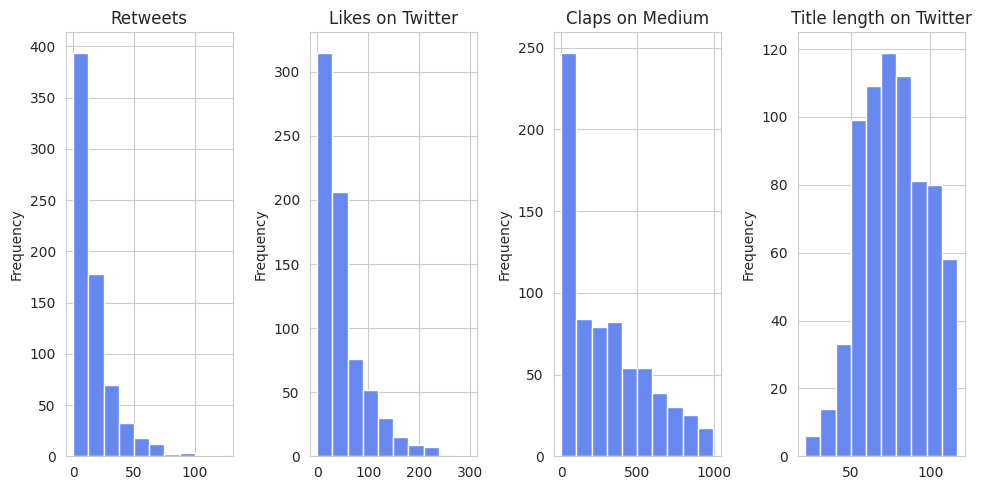

In [8]:
title_length = 'Title Length'
# set the columns that will show statistic and graph
columns = [{'column_name': 'Retweet', 'column_text': 'Retweets'},
           {'column_name': 'Likes', 'column_text': 'Likes on Twitter'},
           {'column_name': 'Claps', 'column_text': 'Claps on Medium'},
           {'column_name': title_length, 'column_text': 'Title length on Twitter'}]

# plot histogram of columns
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    column = title_stat[class_name]
    plt.subplot(1, 4, columns.index(el) + 1)
    plt.tight_layout()
    column.plot.hist(orientation='vertical', cumulative=False, title=el['column_text'])
    if class_name != title_length:
        print('Total {}: {} times'.format(class_name, column.sum()))

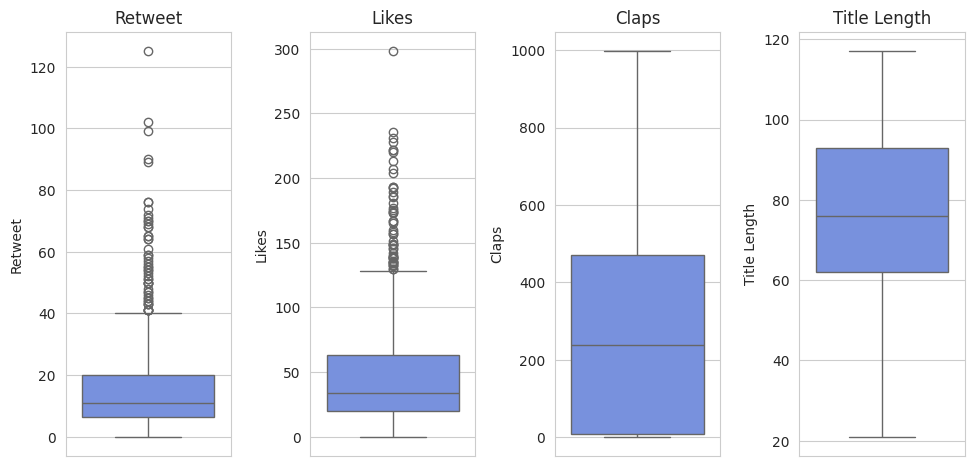

In [9]:
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    column = title_stat[class_name]
    plt.subplot(1, 4, columns.index(el) + 1)
    plt.tight_layout()
    plt.title(class_name);
    sns.boxplot(data=column);

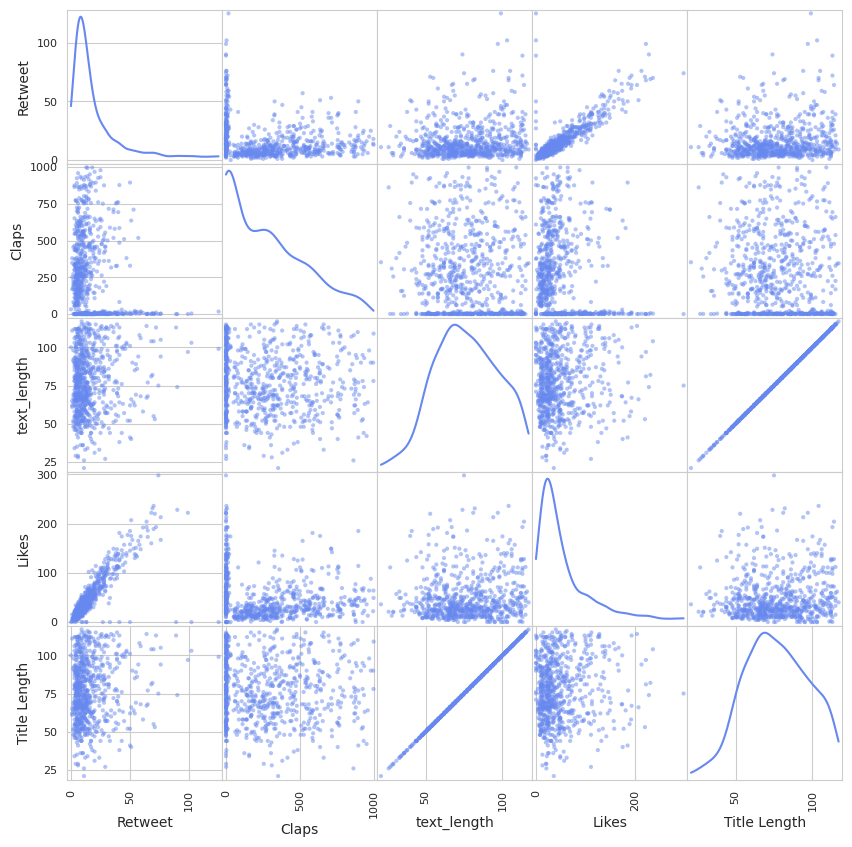

In [10]:
temp = pd.plotting.scatter_matrix(title_stat, diagonal="kde", figsize=(10, 10))


In [11]:
PERCENTAGE = 25

In [12]:
# remove the outlier data ponts. We use the forumla:
# Outlier < Q_1 - 1.5* IQR
# Outlier > Q_3 + 1.5 * IQR
# Where Q_1 and Q_3 are the first and third quartile
# and IQR is the Interquartile Range (IQR = Q_3 - Q_1).
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    non_outliers = (df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)
#     non_outliers = df[column] >= 0
    return df.loc[non_outliers]

In [13]:
def plot_top_length_performers(col_name, is_grouped):
    plt.figure(figsize=(10, 5))
    for el in columns:
        class_name = el['column_name']
        column = title_stat[class_name]
        if class_name != title_length:
            plt.subplot(1, 3, columns.index(el) + 1)
            plt.tight_layout()
            # remove outliers
            title_stat_top = remove_outliers(title_stat, class_name)
            # get top PERCENTAGE%
            title_stat_top = title_stat_top.sort_values(by=[class_name], ascending=False).head(int(len(title_stat)*(PERCENTAGE/100.00)))
            if (is_grouped):
                temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
            else:
                temp = title_stat_top.groupby(title_stat_top[col_name]).count()[class_name]
            temp.plot.bar()
            #sns.despine()
            plt.title('{} frequency'.format(el['column_name']));

<ipython-input-13-f81e8c671754>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
<ipython-input-13-f81e8c671754>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
<ipython-input-13-f81e8c671754>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed

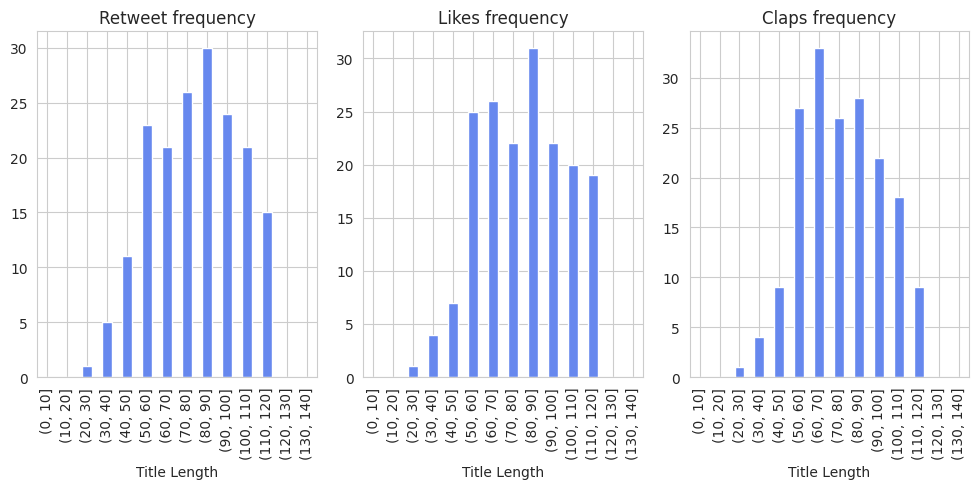

In [14]:
plot_top_length_performers(title_length, True)

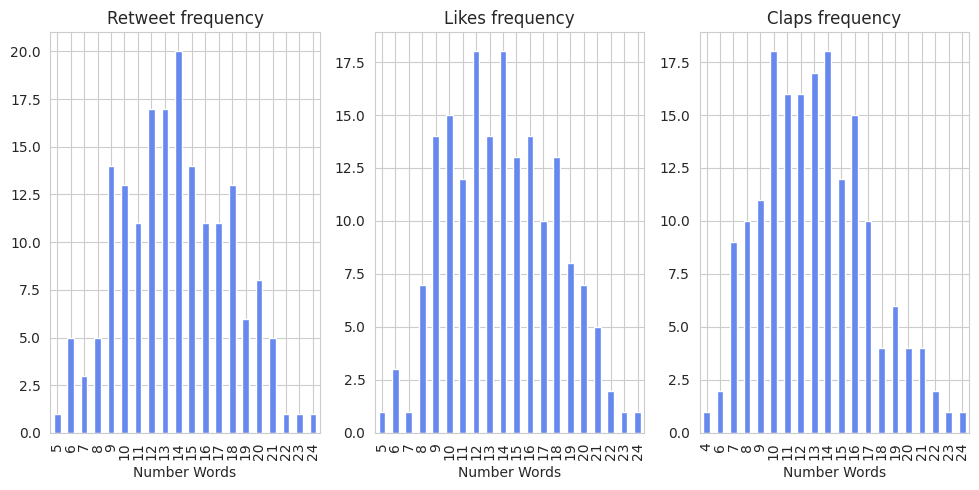

In [15]:
number_words = 'Number Words'
title_stat[number_words] = title_stat['Title'].str.split().apply(len)
plot_top_length_performers(number_words, False)

In [16]:
def plot_top_performers(lst_col):
    for el in columns:
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        if class_name != title_length:
            plt.figure(figsize=(10, 5))
            # remove outliers
            title_stat_top = remove_outliers(title_stat, class_name)
            title_stat_top = title_stat_top.sort_values(by=[class_name], ascending=False).head(int(len(title_stat_top)*(PERCENTAGE/100.00)))
            x = pd.DataFrame({
                    col:np.repeat(title_stat_top[col].values, title_stat_top[lst_col].str.len())
                    for col in title_stat_top.columns.difference([lst_col])
                }).assign(**{lst_col:np.concatenate(title_stat_top[lst_col].values)})[title_stat_top.columns.tolist()]
            temp = x.groupby(lst_col).count()[class_name].sort_values(ascending=False).head(20).sort_values(ascending=True)
            temp.plot.barh()
            #sns.despine()
            plt.title('Most used {} on top {}% {}'.format(lst_col, PERCENTAGE, el['column_text']));

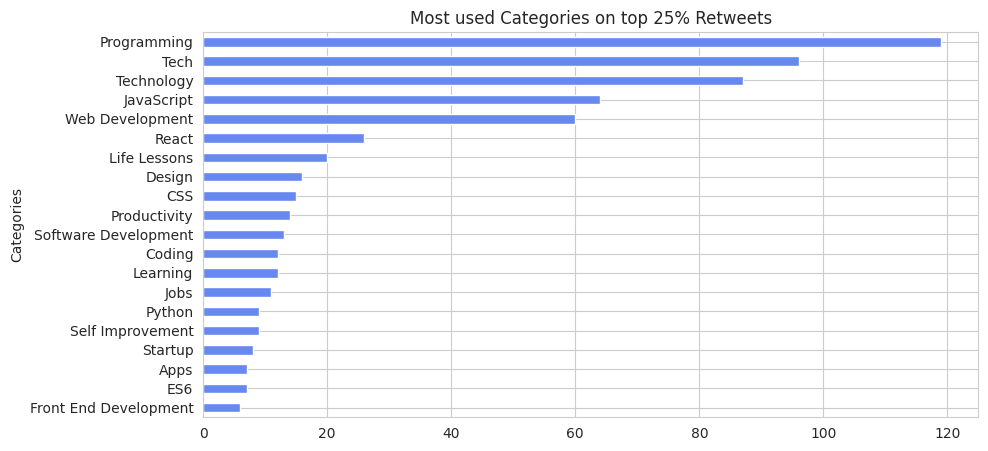

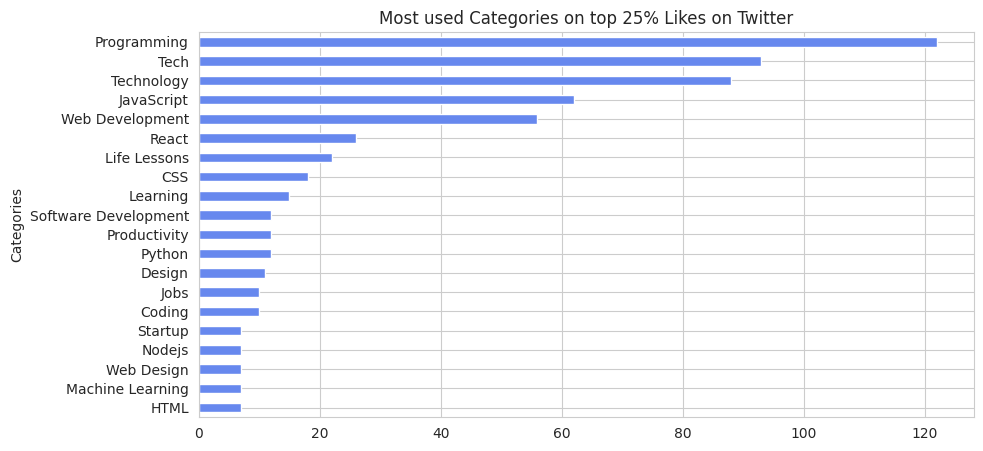

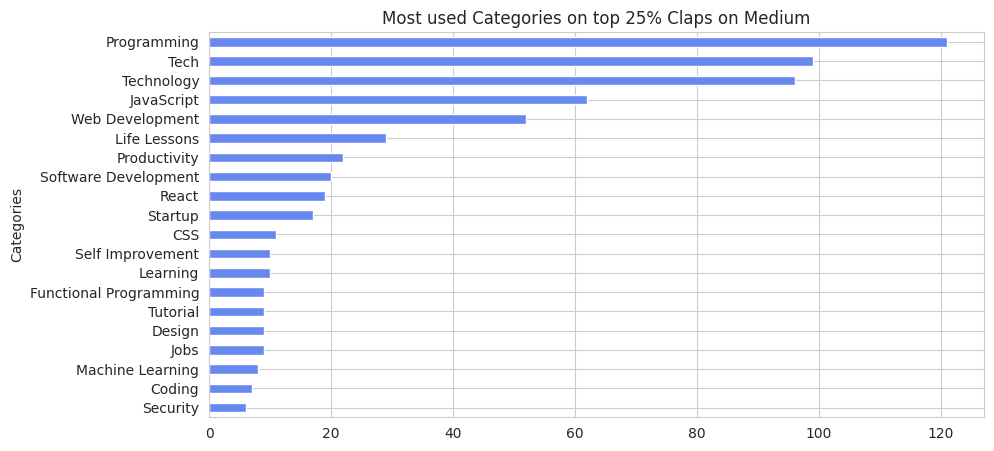

In [17]:
plot_top_performers('Categories')

In [18]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

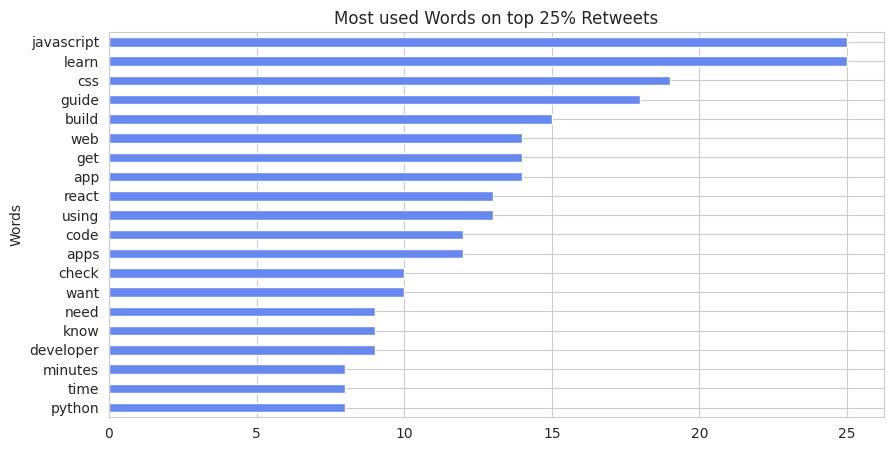

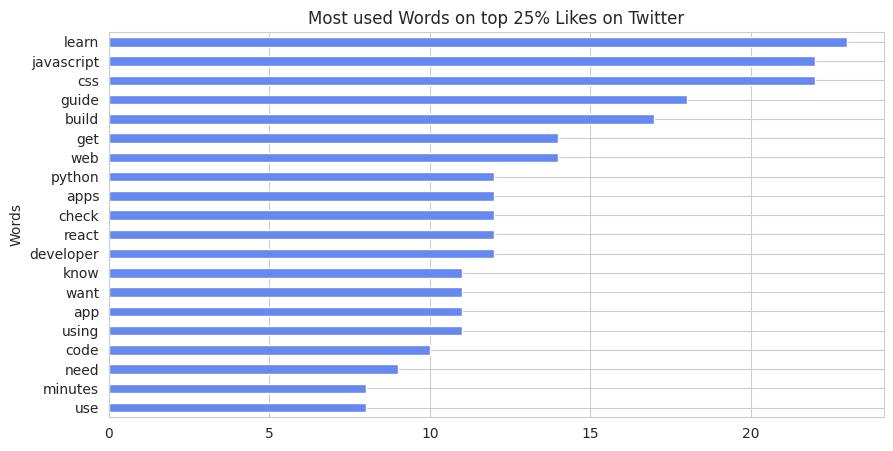

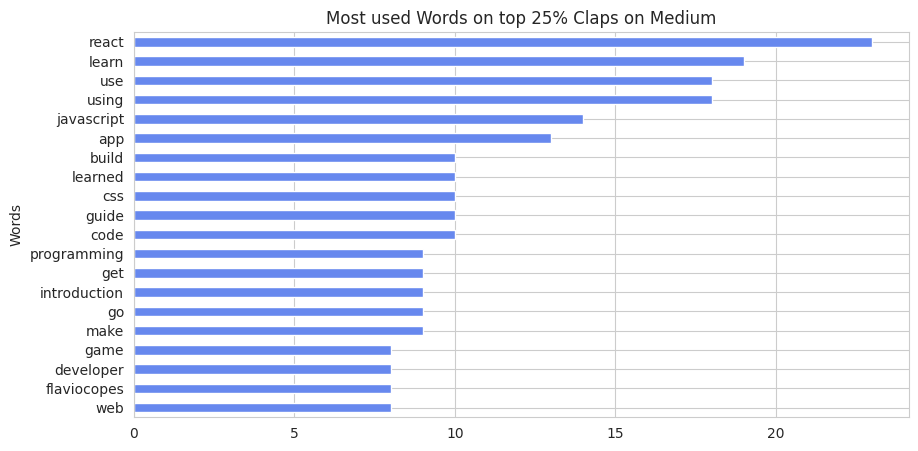

In [19]:
# create a column containing the words of the title
# remove special characters
temp = title_stat['Title'].str.lower().str.translate(str.maketrans('','','()!@#$:"?,./+')).str.split()
# temp = title_stat['Title'].str.lower().str.split()
# remove common words (it, a, the, ...)
stop=set(stopwords.words('english'))
title_stat['Words'] = temp.apply(lambda x: [item for item in x if item not in stop and not '\\' in item])
# title_stat['Words'] = temp
# print(stop) #uncomment to see removed words
# plot relation between the words used on medium title and the number of retweet/favorite/claps. Just for the top PERCENTAGE% performers
#sns.despine()
plot_top_performers('Words')

In [20]:
def get_category_name(column_name):
    return '{} Category'.format(column_name)

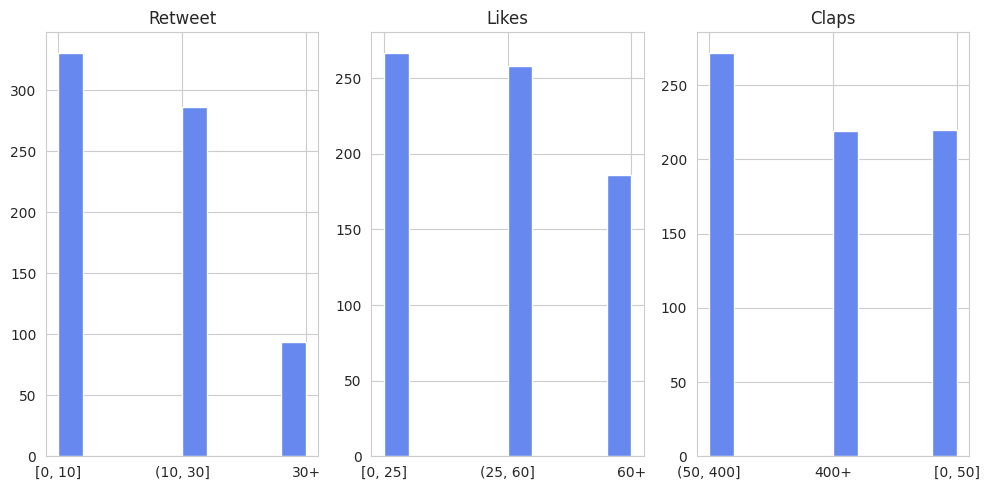

In [21]:
def get_range(value, ranges):
    for idx,max_value in enumerate(ranges):
        if value <= max_value:
            previous = '({}'.format(ranges[idx-1]) if idx >= 1 else '[0'
            return '{}, {}]'.format(previous, max_value)
    return '{}+'.format(ranges[-1])

# plot histogram of columns
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    if class_name != title_length:
        column = title_stat[class_name]
        plt.subplot(1, 3, columns.index(el) + 1)
        plt.tight_layout()
        ranges = {
            'Retweet': [10, 30],
            'Likes': [25, 60],
            'Claps': [50, 400]
        }
        column = [ get_range(a, ranges[class_name]) for a in column ]
        plt.title('{}'.format(class_name))
        pd.DataFrame(column)[0].hist(xrot=0)

        # add classification to dataframe
        title_stat[get_category_name(class_name)] = column

In [22]:
def clean_title(text):
    # remove twitter users, leave @ for stats reason
    text = text.map(lambda x: re.sub('@[_A-Za-z0-9]+','@',str(x)))
    return text


def split_data(title_stat, class_name, is_remove_outlier, is_clean_text):
            # remove outliers
            if is_remove_outlier:
                title_stat_top = remove_outliers(title_stat, class_name)
            else:
                title_stat_top = title_stat

            # Set the number of testing points
            if is_clean_text:
                X_all = clean_title(title_stat_top['Title'])
            else:
                X_all = title_stat_top['Title']
            y_all = title_stat_top[get_category_name(class_name)]

            # Shuffle and split the dataset into the number of training and testing points above
            X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=ratios[class_name], shuffle=False)

            return {
                'title_stat_top': title_stat_top,
                'X_all': X_all,
                'y_all': y_all,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test
            }
X_all = {}
y_all = {}
X_train = {}
X_test = {}
y_train = {}
y_test = {}

ratios = {
    'Retweet': 0.2,
    'Likes': 0.2,
    'Claps': 0.2
}

for el in columns:
    column = title_stat[el['column_name']]
    class_name = el['column_name']
    if class_name != title_length:
        values = split_data(title_stat, class_name, True, True)
        title_stat_top, X_all[class_name], y_all[class_name], X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name] = [values[k] for k in ('title_stat_top', 'X_all','y_all', 'X_train', 'X_test', 'y_train', 'y_test')]

        total = title_stat[class_name].count()
        total_no_outliers = title_stat_top[class_name].count()
        print('{}\nTotal: {} items.\nTotal without outliers: {}'.format(class_name, total, total_no_outliers))

        # Show the results of the split
        print("Training set has {} samples".format(X_train[class_name].shape[0]))
        print("Testing set has {} samples\n".format(X_test[class_name].shape[0]))

Retweet
Total: 711 items.
Total without outliers: 658
Training set has 526 samples
Testing set has 132 samples

Likes
Total: 711 items.
Total without outliers: 658
Training set has 526 samples
Testing set has 132 samples

Claps
Total: 711 items.
Total without outliers: 711
Training set has 568 samples
Testing set has 143 samples



In [23]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import FunctionTransformer

# implement bag of words with td-idf
X_train_word_features = {}
test_features = {}

def get_text_length(x):
    return np.array([len(t) for t in x]).reshape(-1, 1)

def get_words_length(x):
    return np.array([len(t.split()) for t in x]).reshape(-1, 1)

def to_array(x):
    return x.toarray()

In [24]:

# load classifiers
# Initialize the models
# for each classifier was defined (code bellow: Best features) the best parameters for each feature
# if the best parameters calculated for the model is the same as default, i will mark as #DEFAULT
classifiers = [
    # no parameter to test for the model GaussianNB()
    {
        'classifier': GaussianNB(),
        'toarray': True,
        'parameters': {}
    },
    {
        'classifier': LogisticRegression(),
        'toarray': False,
        'parameters': {
            'C': [0.1, 0.5, 1, 2, 10],
            'fit_intercept': [True, False],
            'class_weight': ['balanced', None],
            'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
            'max_iter': [10, 100, 300]
        }
    },
    {
        'classifier': DecisionTreeClassifier(),
        'toarray': False,
        'parameters': {
            'splitter': ['random', 'best'],
            'max_depth': [1, 5, 10, 20, None],
            'class_weight': ['balanced', None]
        }
    },
    {
        'classifier': SVC(),
        'toarray': True,
        'parameters': {
            'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
            'degree':[1, 2, 3, 4, 5, 6, 7],
            'C':[0.5, 1, 2],
        }
    },
    {
        'classifier': KNeighborsClassifier(),
        'toarray': False,
        'parameters': {
            'n_neighbors': [1, 5, 10, 15, 20, 30],
            'weights': ['distance', 'uniform'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'leaf_size': [10, 30, 50],
        }
    },
    {
        'classifier': MultinomialNB(),
        'toarray': False,
        'parameters': {
                'alpha': [0, 0.5, 1],
                'fit_prior': [True, False]
        }
    },
    {
        'classifier': GradientBoostingClassifier(),
        'toarray': False,
        'parameters': {
            'learning_rate': [0.1, 0.5, 1.0],
            'loss': ['deviance'],
            'max_depth': [3, 5, 10],
            'max_features': [None],
            'min_samples_leaf': [1, 2],
            'min_samples_split': [0.1, 0.5, 1.0],
            'min_weight_fraction_leaf': [0.0],
            'n_estimators': [50, 100],
            'random_state': [0, None],
            'subsample': [1.0],
            'warm_start': [False]
        }
    }
]

In [25]:
from sklearn.metrics import accuracy_score

def get_score_pipeline(classifier_algo, X_train, y_train):
    classifier = Pipeline([
        ('features', FeatureUnion([
            ('text', Pipeline([
                ('vectorizer', TfidfVectorizer(#TfidfVectorizer#CountVectorizer
                                    stop_words='english',
                                    strip_accents='unicode',
                                    token_pattern=r'\w{1,}',
                                    analyzer='word',
                                    ngram_range=(1, 1),
                                )),
                ('toarray', Pipeline([
                    ('count', FunctionTransformer(to_array, validate=False)),
                ]))
            ])),
            ('length', Pipeline([
                ('count', FunctionTransformer(get_text_length, validate=False)),
            ])),
            ('size', Pipeline([
                ('count', FunctionTransformer(get_words_length, validate=False)),
            ]))
        ])),
        ('clf', OneVsRestClassifier(classifier_algo))])

    cv_score = np.mean(cross_val_score(classifier, X_train, y_train, cv=5, scoring='accuracy'))
    print('\t\tAccuracy score: {}'.format(cv_score))
    return cv_score

def get_score(classifier_algo, X_train, X_test, y_train, y_test, name, is_td_idf=True, is_stop_word=True):
    tokens = tokenize(X_train, X_test, is_td_idf, is_stop_word)
    _X_train = tokens['X_train']
    _X_test = tokens['X_test']

    # fit model
    classifier_algo.fit(_X_train, y_train)
    # predict
    y_pred = classifier_algo.predict(_X_test)
    # measure
    cv_score = accuracy_score(y_test, y_pred)
    print('\t\tAccuracy score ({}): {}'.format(name, cv_score))
    return cv_score

def set_statistic_score(class_name, cv_score, model_name, accuracy, classifier_name):
    # store value, if better than others
    if class_name not in accuracy or accuracy[class_name] < cv_score:
        accuracy[class_name] = cv_score
        classifier_name[class_name] = model_name

def print_complete_stat(X_train, X_test, y_train, y_test):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(X_test, y_test))

def tokenize(X_train, X_test, is_td_idf=True, is_stop_word=True):
    if is_td_idf:
        tokenizr = TfidfVectorizer
    else:
        tokenizr = CountVectorizer

    stop_words = 'english' if is_stop_word else None

    word_vectorizer = tokenizr(
        stop_words=stop_words,
        strip_accents='unicode',
        token_pattern=r'\w{1,}',
        analyzer='word',
        ngram_range=(1, 1)
    )

    word_vectorizer.fit(X_train)
    _X_train = word_vectorizer.transform(X_train).toarray()  # <-- change here
    _X_train = np.append(_X_train, get_text_length(X_train), axis=1)
    _X_train = np.append(_X_train, get_words_length(X_train), axis=1)

    _X_test = word_vectorizer.transform(X_test).toarray()  # <-- and here
    _X_test = np.append(_X_test, get_text_length(X_test), axis=1)
    _X_test = np.append(_X_test, get_words_length(X_test), axis=1)

    return {
        'X_train': _X_train,
        'X_test': _X_test
    }


def set_score_stat(classifier_algo, class_name, X_train, X_test, y_train, y_test, accuracy, classifier_name, is_default):
    name_type = 'default' if is_default else 'optimized'
    name = '{} ({})'.format(classifier_algo.__class__.__name__, name_type)
    # cv_score = get_score_pipeline(classifier_algo, X_all[class_name], y_all[class_name])
    cv_score = get_score(classifier_algo, X_train, X_test, y_train, y_test, name_type)
    # store value, if better than others
    set_statistic_score(class_name, cv_score, name, accuracy, classifier_name)

In [26]:
classifier_name = {}
accuracy = {}

print('Default classifiers')
for clf in classifiers:
    print("==== Classifier: {} ====".format(clf['classifier'].__class__.__name__))
    for el in columns:
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        if class_name != title_length:
            name = 'classifier-{}'.format(class_name)
            # if there is a specific model refined, use it
            classifier_algo = clf[name] if name in clf else clf['classifier']
            print('\t==== {} ===='.format(class_name))

            # calculate score and add to statistic
            set_score_stat(classifier_algo, class_name, X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name], accuracy, classifier_name, True)

            # print_complete_stat(X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name])

print('Best scores:')
print(accuracy)
print(classifier_name)

Default classifiers
==== Classifier: GaussianNB ====
	==== Retweet ====
		Accuracy score (default): 0.49242424242424243
	==== Likes ====
		Accuracy score (default): 0.4621212121212121
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
==== Classifier: LogisticRegression ====
	==== Retweet ====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


		Accuracy score (default): 0.5909090909090909
	==== Likes ====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


		Accuracy score (default): 0.4621212121212121
	==== Claps ====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


		Accuracy score (default): 0.4965034965034965
==== Classifier: DecisionTreeClassifier ====
	==== Retweet ====
		Accuracy score (default): 0.5378787878787878
	==== Likes ====
		Accuracy score (default): 0.4696969696969697
	==== Claps ====
		Accuracy score (default): 0.3356643356643357
==== Classifier: SVC ====
	==== Retweet ====
		Accuracy score (default): 0.5454545454545454
	==== Likes ====
		Accuracy score (default): 0.49242424242424243
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
==== Classifier: KNeighborsClassifier ====
	==== Retweet ====
		Accuracy score (default): 0.5
	==== Likes ====
		Accuracy score (default): 0.3939393939393939
	==== Claps ====
		Accuracy score (default): 0.3706293706293706
==== Classifier: MultinomialNB ====
	==== Retweet ====
		Accuracy score (default): 0.6060606060606061
	==== Likes ====
		Accuracy score (default): 0.4090909090909091
	==== Claps ====
		Accuracy score (default): 0.3146853146853147
==== Classifier: GradientBoostingClassifi

In [ ]:
from sklearn.grid_search import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack

# Looking for: Best features
# Fine tune the chosen model. Using grid search (GridSearchCV) with at least one
# important parameter tuned with at least 3 different values.
# You will need to use the entire training set for this. In the code cell below, you will need to implement the following:

accuracy = {}
classifier_name = {}
import warnings; warnings.simplefilter('ignore')
for classifier in classifiers:
    for el in columns:
    #     el = {'column_name': 'Retweet', 'column_text': 'Retweets'}
    #     el = {'column_name': 'Favorites', 'column_text': 'Favorites on Twitter'}
    #     el = {'column_name': 'Claps', 'column_text': 'Claps on Medium'}
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        clf = classifier['classifier']
        parameters = classifier['parameters']
        print("==== Classifier: {} ====".format(clf.__class__.__name__))
        if class_name != title_length:
            print('\t==== {} ===='.format(class_name))

            # calculate score and add to statistic
            set_score_stat(classifier_algo, class_name,
                            X_train[class_name], X_test[class_name],
                           y_train[class_name], y_test[class_name].values,
                           accuracy, classifier_name, True)

            # Grid search on the classifier using the f1_scorer as the scoring method
            grid_obj = GridSearchCV(clf, param_grid = parameters, scoring=make_scorer(accuracy_score))

            tokens = tokenize(X_train[class_name], X_test[class_name])
            _X_train = tokens['X_train']

            # Fit the grid search object to the training data and find the optimal parameters
            grid_obj = grid_obj.fit(_X_train, y_train[class_name])

            # Get the estimator
            print('Model best estimator: {}'.format(grid_obj.best_estimator_))

            models_winners[class_name] = grid_obj.best_estimator_

            # calculate score and add to statistic
            classifier_algo = grid_obj.best_estimator_
            set_score_stat(classifier_algo, class_name,
                            X_train[class_name], X_test[class_name],
                           y_train[class_name], y_test[class_name].values, accuracy, classifier_name, False)

==== Classifier: GaussianNB ====
	==== Retweet ====
		Accuracy score (default): 0.5757575757575758
Model best estimator: GaussianNB(priors=None)
		Accuracy score (optimized): 0.49242424242424243
==== Classifier: GaussianNB ====
	==== Likes ====
		Accuracy score (default): 0.4621212121212121
Model best estimator: GaussianNB(priors=None)
		Accuracy score (optimized): 0.4621212121212121
==== Classifier: GaussianNB ====
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
Model best estimator: GaussianNB(priors=None)
		Accuracy score (optimized): 0.4125874125874126
==== Classifier: GaussianNB ====
==== Classifier: LogisticRegression ====
	==== Retweet ====
		Accuracy score (default): 0.49242424242424243
Model best estimator: LogisticRegression(C=10, class_weight='balanced', dual=False,
          fit_intercept=True, intercept_scaling=1, max_iter=10,
          multi_class='ovr', n_jobs=1, penalty='l2', random_state=None,
          solver='liblinear', tol=0.0001, verbose=0, warm_st

In [ ]:
# Plot for the winners the hit and lost points
models_winners = {
    'Retweet': MultinomialNB(alpha=1, class_prior=None, fit_prior=True),
    'Likes': LogisticRegression(C=10, class_weight=None, dual=False, fit_intercept=False, intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='lbfgs', tol=0.0001, verbose=0, warm_start=False),
    'Claps': LogisticRegression(C=2, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=10, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='liblinear', tol=0.0001, verbose=0, warm_start=False)
}

info = {}
for el in columns:
    column = title_stat[el['column_name']]
    class_name = el['column_name']
    acc = []
    if class_name != title_length:
        print('\t==== {} ===='.format(class_name))

        # how evolved the refinement of the solution
        configurations = [
            {'is_remove_outlier': False, 'is_clean_text': False, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'Benchmark', 'tag': 'benchmark', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': False, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'No outlier', 'tag': 't1', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'No outlier + clean words', 'tag': 't2', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  False, 'title': 'No outlier + clean words + td-idf', 'tag': 't3', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  True, 'title': 'No outlier + clean words + td-idf + stopwords', 'tag': 't4', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  True, 'title': 'Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned', 'tag': 'winner', 'model_winner': True},
        ]

        for c in configurations:
            # run for the benchmark
            print(c['title'])
            classifier_algo = models_winners[class_name] if c['model_winner'] else LogisticRegression()
            values = split_data(title_stat, class_name, c['is_remove_outlier'], c['is_clean_text'])
            title_stat_top2, X2_all, y2_all, X2_train, X2_test, y2_train, y2_test = [values[k] for k in ('title_stat_top', 'X_all','y_all', 'X_train', 'X_test', 'y_train', 'y_test')]
            acc.append(get_score(classifier_algo, X2_train, X2_test, y2_train, y2_test, c['tag'], c['is_td_idf'], c['is_stop_word']))

        info[class_name] = pd.DataFrame({
            'evolution': ['benchmark', 't1', 't2', 't3', 't4', 'winner'],
            'accuracy': list(map(lambda x: 100*x, acc))
        })


	==== Retweet ====
Benchmark
		Accuracy score (benchmark): 0.5734265734265734
No outlier
		Accuracy score (t1): 0.5909090909090909
No outlier + clean words
		Accuracy score (t2): 0.5833333333333334
No outlier + clean words + td-idf
		Accuracy score (t3): 0.5984848484848485
No outlier + clean words + td-idf + stopwords
		Accuracy score (t4): 0.5909090909090909
Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned
		Accuracy score (winner): 0.6060606060606061
	==== Likes ====
Benchmark
		Accuracy score (benchmark): 0.5454545454545454
No outlier
		Accuracy score (t1): 0.5075757575757576
No outlier + clean words
		Accuracy score (t2): 0.5303030303030303
No outlier + clean words + td-idf
		Accuracy score (t3): 0.4772727272727273
No outlier + clean words + td-idf + stopwords
		Accuracy score (t4): 0.45454545454545453
Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned
		Accuracy score (winner): 0.5606060606060606
	==== Claps ====
Benchmar

** Accuracy Retweet (%)**  

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
|  0 | Benchmark | 57.34 | -- |
|  1 | LogisticRegression | 49.24 | 53.79 |
|  2 | GaussianNB | 59.09 | 49.24 |
|  3 | DecisionTreeClassifier | 56.06 | 54.54
|  4 | SVC | 55.30 | 57.58 |
|  5 | KNeighborsClassifier | 57.58 | 55.30 |
|  6 | **MultinomialNB** | 47.72 | **60.61** |
|  7 | GradientBoostingClassifier | 56.82 | 55.30 |

** Accuracy Likes (%)**  

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
| 0 |  Benchmark | 53.15 | -- |
| 1 |  **LogisticRegression** | **55.30** | 45.45 |
| 2  | GaussianNB | 46.21 | 46.21 |
| 3  | DecisionTreeClassifier | 43.18 | 45.45 |
| 4  | SVC | 51.51 | 51.51 |
| 5  | KNeighborsClassifier | 44.70 | 46.21 |
| 6 | MultinomialNB | 40.91 | 45.45 |
| 7 | GradientBoostingClassifier | 47.73 | 48.48 |



** Accuracy Claps (%)**  

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
|  0 | Benchmark | 42.65 | -- |
| 1 | **LogisticRegression** | 46.85 | **48.95**
|  2 | GaussianNB | 41.26 | 41.26 |
|  3 | DecisionTreeClassifier | 37.06 | 44.06 |
|  4 | SVC | 49.65 | 49.65 |
|  5 | KNeighborsClassifier | 39.16 | 41.95 |
|  6 | MultinomialNB | 42.66 | 42.66 |
|  7 | GradientBoostingClassifier | 44.76 | 37.76 |


** Tuned Parameters Retweet (%)**  

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | C=10, class_weight=None, dual=False, fit_intercept=False, intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='lbfgs', tol=0.0001, verbose=0, warm_start=False |
| 2 | priors=None |
| 3 | class_weight='balanced', criterion='gini', max_depth=20, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, presort=False, random_state=None, splitter='best' |
| 4 | C=1, cache_size=200, class_weight=None, coef0=0.0, decision_function_shape='ovr', degree=1, gamma='auto', kernel='linear', max_iter=-1, probability=False, random_state=None, shrinking=True, tol=0.001, verbose=False |
| 5 | algorithm='auto', leaf_size=10, metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=10, p=2, weights='uniform' |
| 6 | alpha=1, class_prior=None, fit_prior=True |
| 7 | criterion='friedman_mse', init=None, learning_rate=0.5, loss='deviance', max_depth=10, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=2, min_samples_split=1.0, min_weight_fraction_leaf=0.0, n_estimators=50, presort='auto', random_state=None, subsample=1.0, verbose=0, warm_start=False |


** Tuned Parameters Likes (%)**  

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | C=1, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='liblinear', tol=0.0001, verbose=0, warm_start=False |
| 2 | priors=None |
| 3 | class_weight=None, criterion='gini', max_depth=None, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, presort=False, random_state=None, splitter='best' |
| 4 | C=1, cache_size=200, class_weight=None, coef0=0.0, decision_function_shape='ovr', degree=1, gamma='auto', kernel='linear', max_iter=-1, probability=False, random_state=None, shrinking=True, tol=0.001, verbose=False |
| 5 | algorithm='auto', leaf_size=50, metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=20, p=2, weights='uniform' |
| 6 | alpha=0.5, class_prior=None, fit_prior=True |
| 7 | criterion='friedman_mse', init=None, learning_rate=0.1, loss='deviance', max_depth=10, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=2, min_samples_split=0.5, min_weight_fraction_leaf=0.0, n_estimators=100, presort='auto', random_state=None, subsample=1.0, verbose=0, warm_start=False |



** Tuned Parameters Claps (%)**  

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | C=2, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=10, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='liblinear', tol=0.0001, verbose=0, warm_start=False |
| 2 | priors=None |
| 3 | class_weight=None, criterion='gini', max_depth=10, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0, presort=False, random_state=None, splitter='random' |
| 4 | C=1, cache_size=200, class_weight=None, coef0=0.0, decision_function_shape='ovr', degree=1, gamma='auto', kernel='linear', max_iter=-1, probability=False, random_state=None, shrinking=True, tol=0.001, verbose=False |
| 5 | algorithm='auto', leaf_size=30, metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=20, p=2, weights='uniform' |
| 6 | alpha=0.5, class_prior=None, fit_prior=True |
| 7 | criterion='friedman_mse', init=None, learning_rate=0.5, loss='deviance', max_depth=3, max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, min_samples_leaf=1, min_samples_split=0.5, min_weight_fraction_leaf=0.0, n_estimators=100, presort='auto', random_state=0, subsample=1.0, verbose=0, warm_start=False |


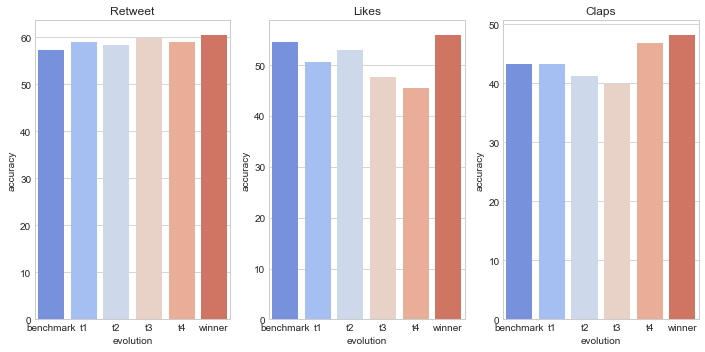

In [ ]:
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    if class_name != title_length:
        plt.subplot(1, 3, columns.index(el) + 1)
        plt.tight_layout()
        plt.title(class_name);
        values = info[class_name]
        sns.barplot(values['evolution'], values['accuracy'])
        #sns.despine()